# Compare MergedSimCluster vs MergedCaloTruthMergedSimCluster

Compare the two collections from `taus.parquet`:\n- number of objects per event\n- energy (`recEnergy`)\n- 3D position (impact point x, y, z)\n- angles (impact point eta, phi)\n\nFor each variable: overlaid 1D distributions on top, ratio (MergedSimCluster / MergedCaloTruthMergedSimCluster) below. Plots are saved to `/eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots`.

In [ ]:
import os
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

In [2]:
input_file = "/eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/taus.parquet"
output_dir = "/eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots"
os.makedirs(output_dir, exist_ok=True)

events = ak.from_parquet(input_file)
print(events.type)

1000 * {"RecHitHGC": {"RecHitHGC_detId": var * int32, "RecHitHGC_energy": var * float32, "RecHitHGC_time": var * float32, "RecHitHGC_LayerCluster_MatchIdx": var * int32, "RecHitHGC_x": var * float32, "RecHitHGC_y": var * float32, "RecHitHGC_z": var * float32, "RecHitHGC_LayerClusterNumMatch": var * int32, "RecHitHGC_MergedCaloTruthMergedSimClusterBestMatchIdx": var * int32, "RecHitHGC_MergedCaloTruthMergedSimClusterBestMatchQual": var * int32, "RecHitHGC_MergedSimClusterBestMatchIdx": var * int32, "RecHitHGC_MergedSimClusterBestMatchQual": var * int32, "RecHitHGC_SimClusterBestMatchIdx": var * int32, "RecHitHGC_SimClusterBestMatchQual": var * int32}, "MergedSimCluster": {"MergedSimCluster_bunchCrossing": var * int32, "MergedSimCluster_eventId": var * int32, "MergedSimCluster_pdgId": var * int32, "MergedSimCluster_trackIdAtBoundary": var * int32, "MergedSimCluster_boundaryEnergy": var * float32, "MergedSimCluster_impactPoint_eta": var * float32, "MergedSimCluster_impactPoint_phi": var *

In [3]:
collections = {
    "MergedSimCluster": events["MergedSimCluster"],
    "MergedCaloTruthMergedSimCluster": events["MergedCaloTruthMergedSimCluster"],
}

# short field name (without the collection prefix) -> (display name, x-axis label)
variables = {
    "n_objects": ("number of objects", "N objects / event"),
    "recEnergy": ("energy", "energy [GeV]"),
    "impactPoint_x": ("x", "impact point x [cm]"),
    "impactPoint_y": ("y", "impact point y [cm]"),
    "impactPoint_z": ("z", "impact point z [cm]"),
    "impactPoint_eta": ("eta", "impact point $\\eta$"),
    "impactPoint_phi": ("phi", "impact point $\\phi$ [rad]"),
}


def get_flat_values(collection, name, coll_name):
    if name == "n_objects":
        return ak.to_numpy(ak.num(collection[f"{coll_name}_pdgId"], axis=1))
    return ak.to_numpy(ak.flatten(collection[f"{coll_name}_{name}"], axis=None))

In [ ]:
def plot_comparison(values1, values2, label1, label2, xlabel, title, bins=50, xrange=None, save_path=None):
    if xrange is None:
        combined = np.concatenate([values1, values2])
        xrange = (combined.min(), combined.max())
    edges = np.linspace(xrange[0], xrange[1], bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    counts1, _ = np.histogram(values1, bins=edges)
    counts2, _ = np.histogram(values2, bins=edges)

    ratio = np.divide(
        counts1, counts2,
        out=np.full_like(counts1, np.nan, dtype=float),
        where=counts2 > 0,
    )

    fig, (ax_main, ax_ratio) = plt.subplots(
        nrows=2, ncols=1, sharex=True, figsize=(8, 8),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    )

    hep.histplot(counts1, edges, ax=ax_main, label=label1, histtype="step", linewidth=2)
    hep.histplot(counts2, edges, ax=ax_main, label=label2, histtype="step", linewidth=2)
    ax_main.set_ylabel("Counts")
    ax_main.set_title(title)
    ax_main.legend(fontsize=14)

    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax_ratio.plot(centers, ratio, "o", color="black", markersize=3)
    ax_ratio.set_xlabel(xlabel)
    ax_ratio.set_ylabel(f"Ratio {label1} / {label2}", fontsize=8)
    ax_ratio.set_ylim(0, 2)

    fig.align_ylabels([ax_main, ax_ratio])

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig, (ax_main, ax_ratio)

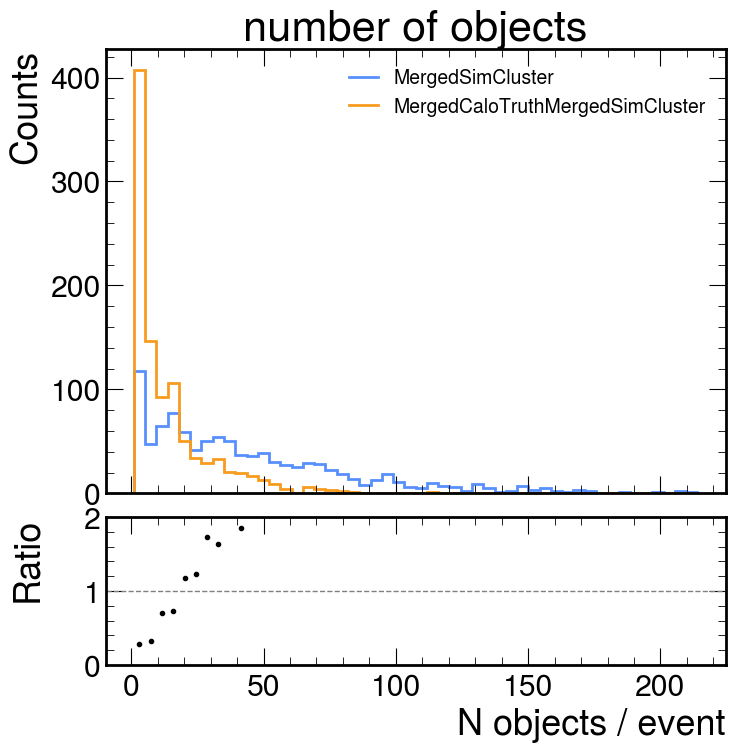

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_n_objects.png


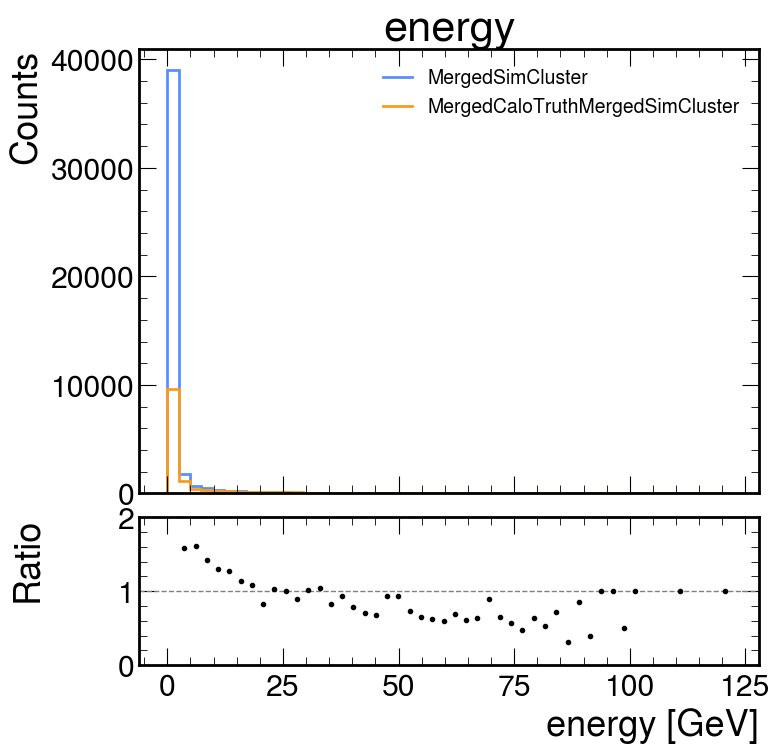

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_recEnergy.png


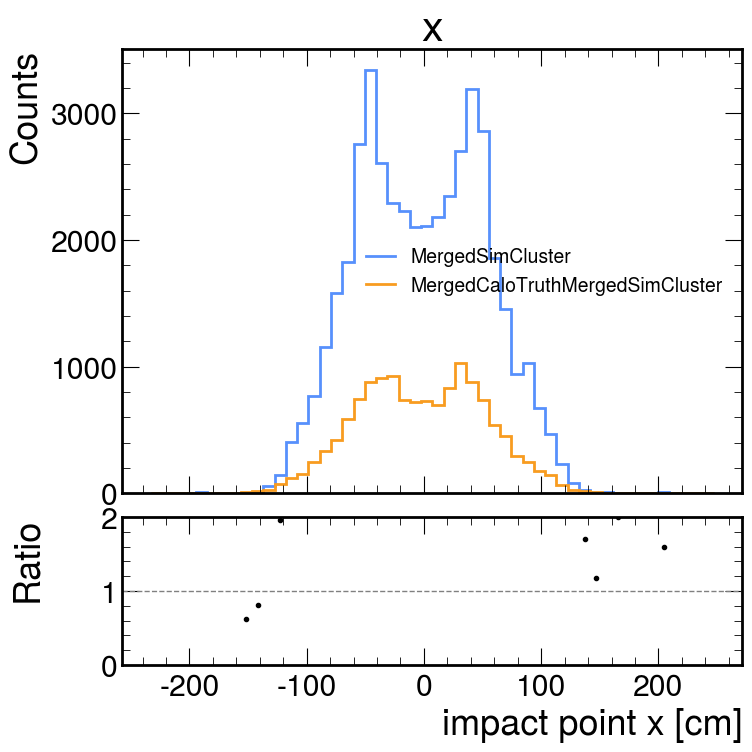

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_impactPoint_x.png


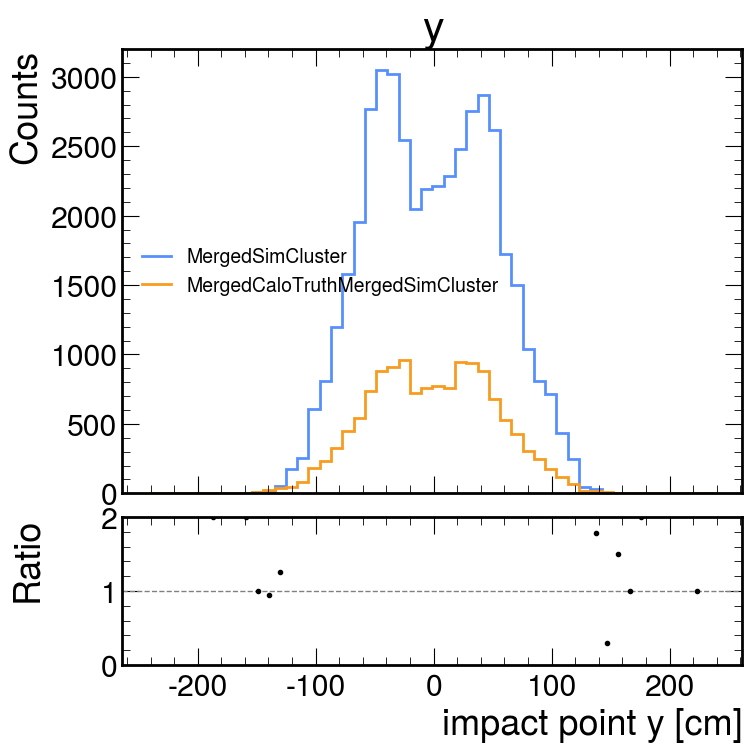

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_impactPoint_y.png


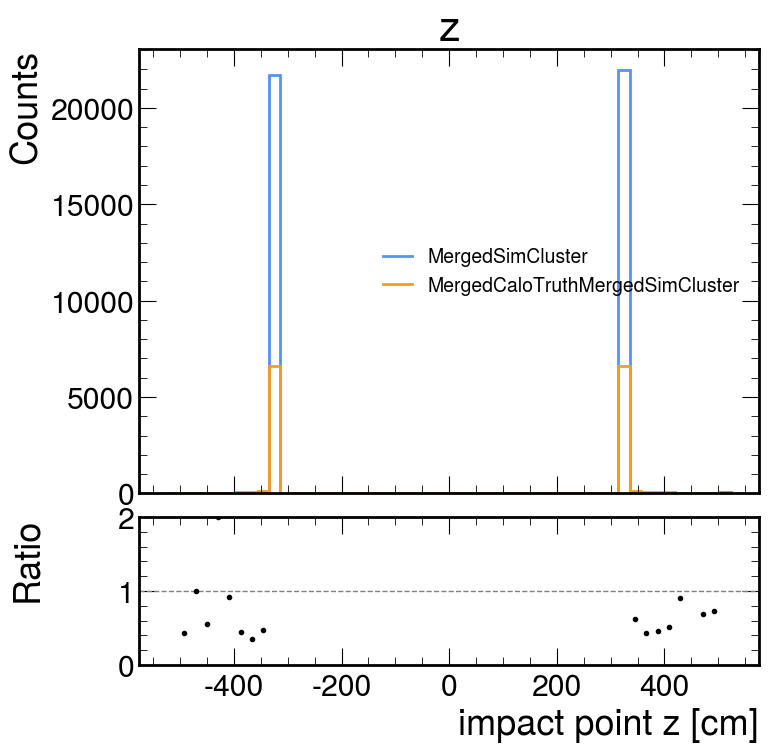

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_impactPoint_z.png


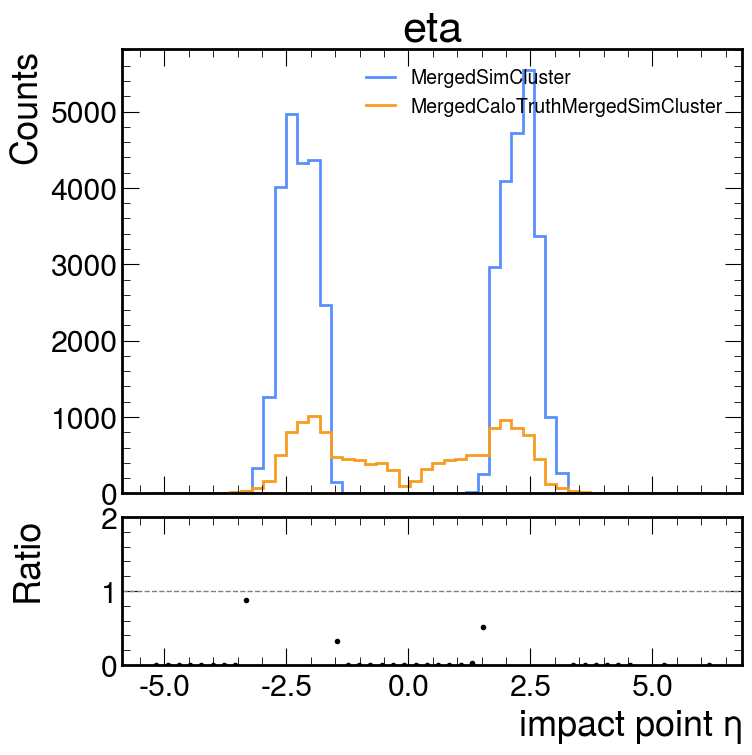

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_impactPoint_eta.png


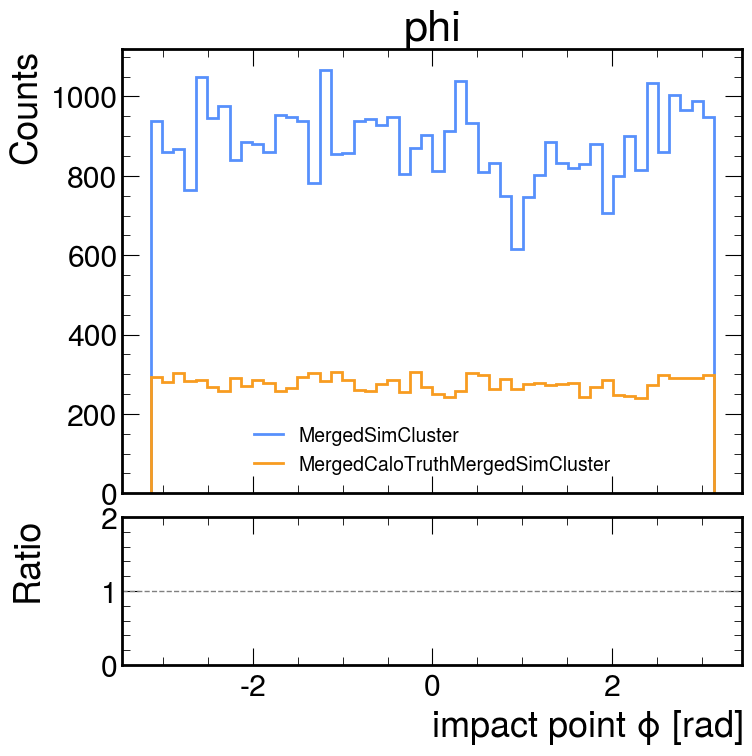

Saved: /eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots/compare_impactPoint_phi.png


In [ ]:
label1, label2 = "MergedSimCluster", "MergedCaloTruthMergedSimCluster"

for yscale in ["linear", "log"]:
    for field, (title, xlabel) in variables.items():
        values1 = get_flat_values(collections[label1], field, label1)
        values2 = get_flat_values(collections[label2], field, label2)

        save_path = os.path.join(output_dir, f"compare_{field}_{yscale}.png")
        fig, _ = plot_comparison(
            values1, values2,
            label1=label1, label2=label2,
            xlabel=xlabel, title=title,
            save_path=save_path,
        )
        plt.show()
        print(f"Saved: {save_path}")